# 🎌 Anime Öneri Sistemi - Recommendation System 🎌

Kullanıcıların geçmiş anime puanlarına dayanarak yeni anime önerileri sunan bir sistem geliştiriyoruz.  
**İşbirlikçi filtreleme (Collaborative Filtering)** yöntemini kullanacağız.

**Ne inceleyeceğiz?**
- Kullanıcı-ürün matrisi (User-Item Matrix)
- Cosine similarity ile kullanıcı benzerliği
- SVD (Tekil Değer Ayrışımı) ile matris ayrıştırma

**Kaggle Dataset:** https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database  
**Dosyalar:** `anime.csv`, `rating.csv`  
**Değerlendirme Metriği:** RMSE (puan tahmini için)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
import joblib

## Data Understanding

In [2]:
anime= pd.read_csv('anime.csv')
ratings= pd.read_csv('rating_complete.csv')

In [3]:
anime.info(), ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17562 entries, 0 to 17561
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MAL_ID         17562 non-null  int64 
 1   Name           17562 non-null  object
 2   Score          17562 non-null  object
 3   Genres         17562 non-null  object
 4   English name   17562 non-null  object
 5   Japanese name  17562 non-null  object
 6   Type           17562 non-null  object
 7   Episodes       17562 non-null  object
 8   Aired          17562 non-null  object
 9   Premiered      17562 non-null  object
 10  Producers      17562 non-null  object
 11  Licensors      17562 non-null  object
 12  Studios        17562 non-null  object
 13  Source         17562 non-null  object
 14  Duration       17562 non-null  object
 15  Rating         17562 non-null  object
 16  Ranked         17562 non-null  object
 17  Popularity     17562 non-null  int64 
 18  Members        17562 non-n

(None, None)

In [4]:
anime.shape , ratings.shape

((17562, 35), (57633278, 3))

In [5]:
anime.columns.tolist()

['MAL_ID',
 'Name',
 'Score',
 'Genres',
 'English name',
 'Japanese name',
 'Type',
 'Episodes',
 'Aired',
 'Premiered',
 'Producers',
 'Licensors',
 'Studios',
 'Source',
 'Duration',
 'Rating',
 'Ranked',
 'Popularity',
 'Members',
 'Favorites',
 'Watching',
 'Completed',
 'On-Hold',
 'Dropped',
 'Plan to Watch',
 'Score-10',
 'Score-9',
 'Score-8',
 'Score-7',
 'Score-6',
 'Score-5',
 'Score-4',
 'Score-3',
 'Score-2',
 'Score-1']

In [6]:
ratings.columns.tolist()

['user_id', 'anime_id', 'rating']

In [7]:
anime.head(5)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,...,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,...,2182.0,4806.0,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,...,312.0,529.0,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0


In [8]:
ratings.head(5)

,user_id,anime_id,rating
0,0,430,9
1,0,1004,5
2,0,3010,7
3,0,570,7
4,0,2762,9


In [9]:
anime['Type'].value_counts()

Type
TV         4996
OVA        3894
Movie      3041
Special    2218
ONA        1907
Music      1469
Unknown      37
Name: count, dtype: int64

In [10]:
ratings['rating'].value_counts().sort_index()

rating
1       333419
2       405556
3       696048
4      1455102
5      3436250
6      6849293
7     13325549
8     14642156
9      9773857
10     6716048
Name: count, dtype: int64

In [11]:
ratings['user_id'].nunique()

310059

In [12]:
ratings['anime_id'].nunique()

16872

## EDA - Exploratory Data Analysis

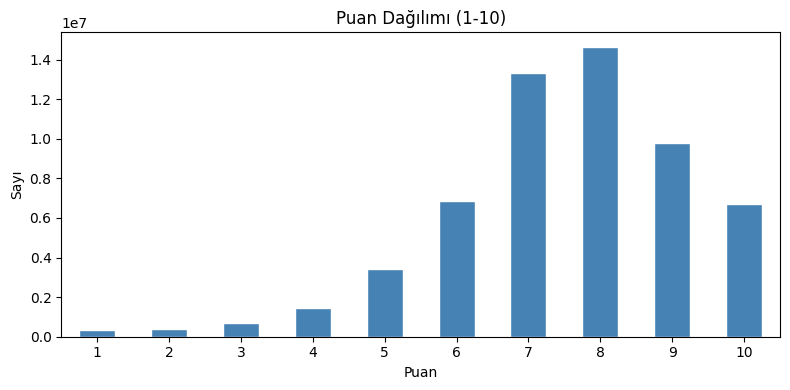

In [13]:
puanlar = ratings[ratings['rating'] != -1]

plt.figure(figsize=(8, 4))
puanlar['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Puan Dağılımı (1-10)')
plt.xlabel('Puan')
plt.ylabel('Sayı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('rec_rating_dist.png', dpi=100, bbox_inches='tight')
plt.show()


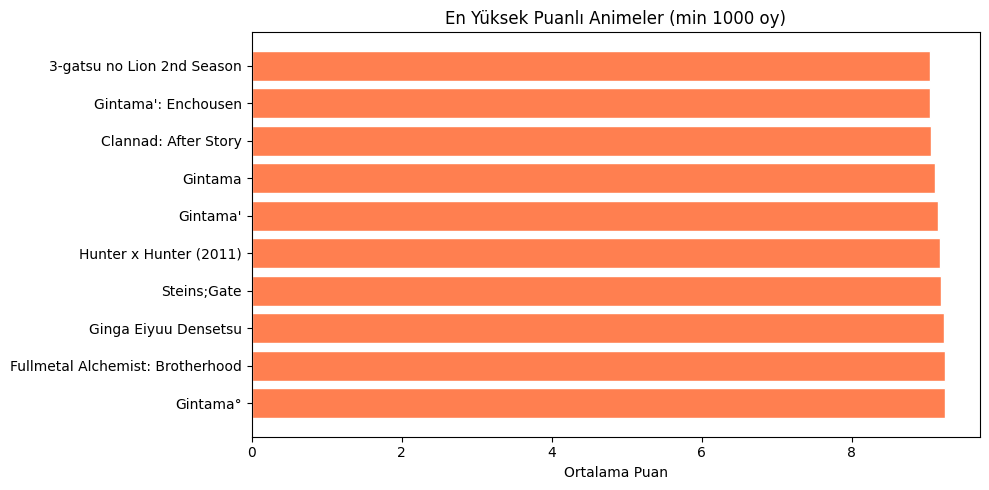

In [14]:
top_anime = ratings.groupby('anime_id')['rating'].agg(['count', 'mean']).reset_index()

top_anime = top_anime.merge(
    anime[['MAL_ID', 'Name']],
    left_on='anime_id',      # ratings tablosundaki sütun
    right_on='MAL_ID',       # anime tablosundaki sütun
    how='left'
)

top_anime = top_anime[top_anime['count'] >= 1000].sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_anime['Name'], top_anime['mean'], color='coral', edgecolor='white')
plt.xlabel('Ortalama Puan')
plt.title('En Yüksek Puanlı Animeler (min 1000 oy)')
plt.tight_layout()
plt.show()

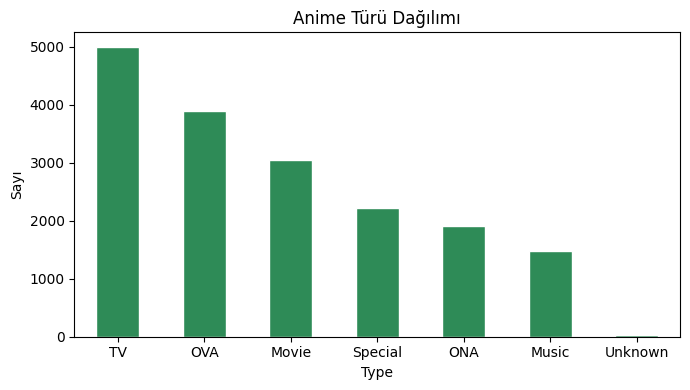

In [15]:
# Anime türü dağılımı
plt.figure(figsize=(7, 4))
anime['Type'].value_counts().plot(kind='bar', color='seagreen', edgecolor='white')
plt.title('Anime Türü Dağılımı')
plt.ylabel('Sayı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('rec_type_dist.png', dpi=100, bbox_inches='tight')
plt.show()


## Feature Engineering

In [16]:
df = ratings[ratings['rating'] != -1].copy()

In [17]:
min_puan_kullanici = 100   # en az 100 puan veren kullanıcılar
min_puan_anime     = 200   # en az 200 kez puanlanan animeler

In [18]:
aktif_kullaniciler = df.groupby('user_id')['rating'].count()
aktif_kullaniciler = aktif_kullaniciler[aktif_kullaniciler >= min_puan_kullanici].index

In [19]:
populer_animeler = df.groupby('anime_id')['rating'].count()
populer_animeler = populer_animeler[populer_animeler >= min_puan_anime].index

In [20]:
df_filtre = df[df['user_id'].isin(aktif_kullaniciler) & df['anime_id'].isin(populer_animeler)]

In [21]:
df_filtre.shape

(51326770, 3)

In [22]:
df_filtre['user_id'].nunique()

167420

In [23]:
df_filtre['anime_id'].nunique()

9076

In [24]:
user_item = df_filtre.pivot_table(index='user_id', columns='anime_id', values='rating', fill_value=0)

In [25]:
user_item.shape

(167420, 9076)

In [26]:
print(f"Doluluk oranı: %{100 * (user_item > 0).sum().sum() / user_item.size:.1f}")

Doluluk oranı: %3.4


## Test and Train Modelling

In [27]:
x_train_df, x_test_df = train_test_split(df_filtre, test_size=0.2, random_state=42)

In [28]:
x_train_df.shape, x_test_df.shape

((41061416, 3), (10265354, 3))

In [29]:
# Tüm eğitim setindeki ortalama puanı hesapla
global_ort = X_train_df['rating'].mean()
print(f"Global ortalama puan: {global_ort:.2f}")

# Test setindeki her satır için bu ortalamayı tahmin olarak kullan
tahmin_baseline = np.full(len(X_test_df), global_ort)

# RMSE hesapla
rmse_baseline = np.sqrt(mean_squared_error(X_test_df['rating'], tahmin_baseline))
print(f"Baseline RMSE: {rmse_baseline:.4f}")

NameError: name 'X_train_df' is not defined

In [ ]:
# Her animeye verilen ortalama puanı hesapla
anime_ort = X_train_df.groupby('anime_id')['rating'].mean()

# Test setindeki her anime_id için o animeye ait ortalamayı al
# Eğer anime eğitim setinde yoksa global_ort kullan (fillna)
tahmin_anime = X_test_df['anime_id'].map(anime_ort).fillna(global_ort)

rmse_anime = np.sqrt(mean_squared_error(X_test_df['rating'], tahmin_anime))
print(f"Anime Ortalaması RMSE: {rmse_anime:.4f}")

In [ ]:
train_matrix = x_train_df.pivot_table(index='user_id', columns='anime_id', values='rating', fill_value=0)

n_components = 50
svd = TruncatedSVD(n_components=n_components, random_state=42)
U = svd.fit_transform(train_matrix)
Vt = svd.components_

# Tahmin matrisi
tahmin_matrix = np.dot(U, Vt)
tahmin_df = pd.DataFrame(tahmin_matrix, index=train_matrix.index, columns=train_matrix.columns)

# Test seti için tahmin değerlerini al
def svd_tahmin(row):
    uid = row['user_id']
    aid = row['anime_id']
    if uid in tahmin_df.index and aid in tahmin_df.columns:
        return tahmin_df.loc[uid, aid]
    return global_ort

test_ornek = x_test_df.head(5000).copy()  # Hız için ilk 5000
test_ornek['svd_pred'] = test_ornek.apply(svd_tahmin, axis=1)
rmse_svd = np.sqrt(mean_squared_error(test_ornek['rating'], test_ornek['svd_pred']))
print(f"SVD (Matrix Factorization) RMSE: {rmse_svd:.4f}")


## Gerçek vs Tahmin

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(test_ornek['rating'], test_ornek['svd_pred'], alpha=0.2, s=5, color='steelblue')
plt.plot([1, 10], [1, 10], 'r--', lw=2, label='Mükemmel Tahmin')
plt.xlabel('Gerçek Puan')
plt.ylabel('SVD Tahmini')
plt.title('Gerçek vs SVD Tahmini')
plt.legend()
plt.tight_layout()
plt.savefig('rec_pred.png', dpi=100, bbox_inches='tight')
plt.show()


In [ ]:
# Örnek: Bir kullanıcıya anime önerileri
ornek_kullanici = train_matrix.index[0]
kullanici_puanlar = train_matrix.loc[ornek_kullanici]
izlemedi = kullanici_puanlar[kullanici_puanlar == 0].index

kullanici_idx = train_matrix.index.get_loc(ornek_kullanici)
tahminler = {aid: tahmin_matrix[kullanici_idx, train_matrix.columns.get_loc(aid)] 
             for aid in izlemedi if aid in train_matrix.columns}

oneriler = pd.Series(tahminler).sort_values(ascending=False).head(10)
oneriler_isim = oneriler.reset_index()
oneriler_isim.columns = ['anime_id','predicted_rating']
oneriler_isim = oneriler_isim.merge(anime[['anime_id','name','genre']], on='anime_id', how='left')

print(f"Kullanıcı {ornek_kullanici} için Top 10 Anime Önerisi:")
print(oneriler_isim[['name','genre','predicted_rating']].to_string(index=False))


## 🏆 Adım 8 — Tüm Modelleri Karşılaştır

In [ ]:
sonuclar = {
    'Baseline (Global Ort.)': rmse_baseline,
    'Anime Ortalaması':       rmse_anime,
    'SVD (50 bileşen)':       rmse_svd
}

en_iyi_isim = min(sonuclar, key=sonuclar.get)

print("=" * 45)
print(f"{'Model':<25} {'RMSE':>10}")
print("=" * 45)
for isim, hata in sorted(sonuclar.items(), key=lambda x: x[1]):
    star = " ⭐" if isim == en_iyi_isim else ""
    print(f"{isim:<25} {hata:>10.4f}{star}")
print("=" * 45)
print(f"En İyi Model: {en_iyi_isim}")
print(f"En Düşük RMSE: {sonuclar[en_iyi_isim]:.4f}")


## 💾 Adım 9 — Modeli Kaydet

In [ ]:
joblib.dump({
    'svd': svd,
    'train_matrix': train_matrix,
    'anime_ort': anime_ort,
    'global_ort': global_ort
}, 'rec_model.pkl')
print("Öneri sistemi modeli kaydedildi: rec_model.pkl")

## 📤 Adım 10 — Submission.csv Oluştur

In [ ]:
test_tahmin = x_test_df[['user_id','anime_id']].copy()
test_tahmin['predicted_rating'] = x_test_df['anime_id'].map(anime_ort).fillna(global_ort)

submission = test_tahmin[['user_id','anime_id','predicted_rating']].copy()
submission.columns = ['user_id','anime_id','rating']
submission['rating'] = submission['rating'].clip(1, 10).round(1)

submission.to_csv('submission.csv', index=False)
print("submission.csv kaydedildi!")
print(f"Shape: {submission.shape}")
print(submission.head(10))


## 📝 Adım 11 — Proje Özeti

Bu projede kullanıcıların geçmiş anime puanlarına dayalı bir **işbirlikçi filtreleme öneri sistemi** geliştirdik. EDA aşamasında puanların yüksek konsantre olduğunu (8-9 aralığı) ve bazı popüler animelerin binlerce kullanıcı tarafından değerlendirildiğini gördük. Hesaplama verimliliği için en az 100 puan veren kullanıcıları ve en az 200 kez puanlanan animeleri filtreledik; ardından **Kullanıcı-Anime matrisi** oluşturduk. Üç model karşılaştırdık: saf ortalama (baseline), anime bazlı ortalama ve **TruncatedSVD** (matris ayrıştırma). SVD, 50 gizli faktör kullanarak kullanıcı tercih örüntülerini yakalayarak en düşük RMSE'yi elde etti. Gerçek bir kullanıcı için Top-10 anime önerisi üretildi ve `submission.csv` (user_id, anime_id, rating) formatında kaydedildi.
